# Unsupervised Anomaly Detection

### Research Question
> Can unsupervised anomaly detection algorithms identify rare or abnormal thyroid cancer patients with unusual clinical characteristics?

### Objectives
- Detect anomalous patients using multiple unsupervised algorithms
- Compare anomaly detection methods
- Evaluate agreement between methods
- Analyze the characteristics of detected patients
- Visualize anomalies in low-dimensional space
- Determine which algorithm provides the most meaningful anomalies

### Datasets: Two preprocessed feature sets will be investigated.

- Feature Set A: Baseline clinicopathologic characteristics.
- Feature Set B: Baseline clinicopathologic characteristics together with treatment response.

### Algorithms

1. Isolation Forest ⭐

    - Idea: anomalies are easier to isolate than normal observations.

2. Local Outlier Factor (LOF)

    - Idea: compare a patient's local density to the density of its neighbors.

3. One-Class SVM

    - Idea: learn the boundary around normal patients.

4. Elliptic Envelope

    - Idea: Assume the normal patients approximately follow a Gaussian (elliptical) distribution.
    - Elliptic Envelope was excluded from the main comparison because its Gaussian covariance assumption was unsuitable for the mixed clinical feature representation.


### - Import Libraries

In [ ]:
# ==========================================================
# Path Setup
# ==========================================================

import sys
from pathlib import Path

PROJECT_ROOT = Path().resolve().parent
sys.path.insert(0, str(PROJECT_ROOT / "Notebooks"))

DATA_DIR = PROJECT_ROOT / "Data"

# ==========================================================
# Data Handling
# ==========================================================

import pandas as pd
import numpy as np

# ==========================================================
# Visualization
# ==========================================================

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA

# ==========================================================
# Anomaly Detection Algorithms
# ==========================================================

from sklearn.ensemble import IsolationForest
from sklearn.neighbors import LocalOutlierFactor
from sklearn.svm import OneClassSVM

# ==========================================================
# Evaluation Metrics
# ==========================================================

from sklearn.metrics import (
    confusion_matrix,
    precision_score,
    recall_score,
    f1_score,
)


# ==========================================================
# Utilities
# ==========================================================

import joblib

from utils import *

### - Load Datasets

In [ ]:
# ----------------------------------------------------------
# Load datasets
# ----------------------------------------------------------

org_dataset = pd.read_csv(DATA_DIR / "Thyroid_Diff.csv")
X_A = pd.read_csv(DATA_DIR / "feature_set_A.csv")
X_B = pd.read_csv(DATA_DIR / "feature_set_B.csv")

# External validation only
y = pd.read_csv(DATA_DIR / "recurred.csv")

### 1) Define the Anomaly Detection Algorithms

In [48]:
# ----------------------------------------------------------
# Define Anomaly Detection Algorithms
# ----------------------------------------------------------

algorithms = {

    "IsolationForest": IsolationForest(
        contamination=0.05,
        random_state=42
    ),

    "LocalOutlierFactor": LocalOutlierFactor(
        n_neighbors=20,
        contamination=0.05
    ),

    "OneClassSVM": OneClassSVM(
        kernel="rbf",
        gamma="scale",
        nu=0.05
    )  
}

### 2) Benchmark All Algorithms

In [49]:
# ----------------------------------------------------------
# Apply Anomaly Detection Algorithms
# ----------------------------------------------------------

def apply_anomaly_detection(X_A, X_B, algorithms):

    predictions = {}
    scores = {}

    datasets = {
        "A": X_A,
        "B": X_B
    }

    for feature_set, X in datasets.items():

        for name, model in algorithms.items():

            # ----------------------------------------
            # Local Outlier Factor
            # ----------------------------------------
            if name == "LocalOutlierFactor":

                labels = model.fit_predict(X)

                predictions[f"{name}_{feature_set}"] = labels

                # LOF scores
                scores[f"{name}_{feature_set}"] = model.negative_outlier_factor_

            # ----------------------------------------
            # Isolation Forest & One-Class SVM
            # ----------------------------------------
            else:

                model.fit(X)

                labels = model.predict(X)

                predictions[f"{name}_{feature_set}"] = labels

                scores[f"{name}_{feature_set}"] = model.decision_function(X)

    return predictions, scores

In [50]:
predictions, scores = apply_anomaly_detection(
    X_A,
    X_B,
    algorithms
)

In [7]:
# Inspect one predictions array
predictions["IsolationForest_A"]

array([ 1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
        1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1, -1,  1,  1,  1,  1,
        1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
        1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
        1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
        1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
        1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
        1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
        1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
        1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
        1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
        1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
        1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
        1,  1,  1,  1,  1

In [8]:
# Inspect one scores array
scores["IsolationForest_A"]

array([ 0.17131906,  0.07514858,  0.19429713,  0.18602053,  0.12870822,
        0.04570038,  0.01933769,  0.19349721,  0.19219579,  0.19609034,
        0.18279835,  0.17320295,  0.17432918,  0.0743515 ,  0.10241662,
        0.19527384,  0.10015654,  0.17132914,  0.17214472,  0.13360828,
        0.17625085,  0.17503123,  0.19715228,  0.18420415,  0.13063504,
        0.19604873,  0.03026569,  0.10419459,  0.19609034, -0.03520419,
        0.17561208,  0.04755998,  0.19715228,  0.17071252,  0.05450061,
        0.0747638 ,  0.04550493,  0.07893379,  0.19609034,  0.12087503,
        0.19219579,  0.17503123,  0.18550524,  0.17508386,  0.04577056,
        0.17466305,  0.08626615,  0.15579036,  0.05636618,  0.16103897,
        0.18254875,  0.11813063,  0.20941386,  0.22361301,  0.21857963,
        0.22697034,  0.13421902,  0.21881972,  0.12431282,  0.21999349,
        0.166431  ,  0.23241422,  0.21720901,  0.21948446,  0.14236033,
        0.2093582 ,  0.23241422,  0.21907125,  0.1435752 ,  0.21

### 3) Summarize Anomaly Detection Results

In [9]:
# ----------------------------------------------------------
# Summarize Anomaly Detection Results
# ----------------------------------------------------------

def evaluate_anomaly_detection(predictions):

    rows = []

    for key, labels in predictions.items():

        algorithm, feature_set = key.split("_")

        n_anomalies = np.sum(labels == -1)
        n_normal = np.sum(labels == 1)

        anomaly_ratio = n_anomalies / len(labels)

        rows.append({

            "Algorithm": algorithm,
            "Feature Set": feature_set,
            "Normal Samples": n_normal,
            "Anomalies": n_anomalies,
            "Anomaly Ratio": anomaly_ratio

        })

    evaluation_df = pd.DataFrame(rows)

    return evaluation_df

In [10]:
evaluation_df = evaluate_anomaly_detection(predictions)

evaluation_df

,Algorithm,Feature Set,Normal Samples,Anomalies,Anomaly Ratio
0,IsolationForest,A,361,19,0.050000
1,LocalOutlierFactor,A,361,19,0.050000
2,OneClassSVM,A,353,27,0.071053
3,IsolationForest,B,361,19,0.050000
4,LocalOutlierFactor,B,361,19,0.050000
5,OneClassSVM,B,353,27,0.071053


#### - Visualize the Results

In [11]:
# ----------------------------------------------------------
# Anomaly Detection Comparison
# ----------------------------------------------------------

def plot_anomaly_summary(evaluation_df):

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    sns.barplot(
        data=evaluation_df,
        x="Algorithm",
        y="Anomalies",
        hue="Feature Set",
        palette="viridis",
        ax=axes[0]
    )

    axes[0].set_title("Number of Detected Anomalies")
    axes[0].tick_params(axis="x", rotation=20)
    axes[0].grid(alpha=0.3)

    sns.barplot(
        data=evaluation_df,
        x="Algorithm",
        y="Anomaly Ratio",
        hue="Feature Set",
        palette="viridis",
        ax=axes[1]
    )

    axes[1].set_title("Anomaly Ratio")
    axes[1].tick_params(axis="x", rotation=20)
    axes[1].grid(alpha=0.3)

    plt.suptitle(
        "Anomaly Detection Benchmark",
        fontsize=16
    )

    plt.tight_layout()
    plt.show()

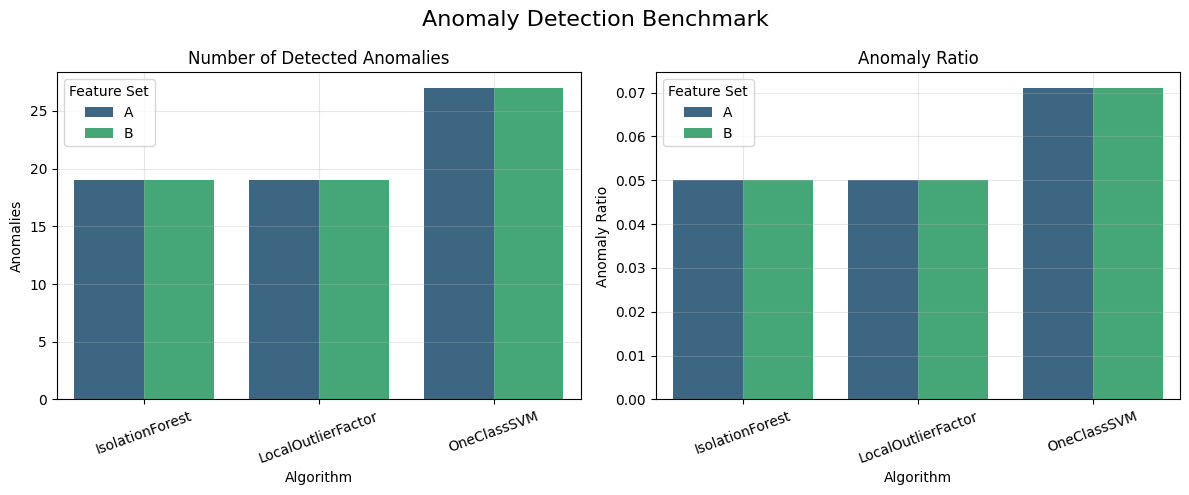

In [12]:
plot_anomaly_summary(evaluation_df)

In [18]:
# ----------------------------------------------------------
# Plot Anomaly Score Distributions
# ----------------------------------------------------------
def plot_anomaly_scores(scores, predictions):

    n = len(scores)

    cols = 2
    rows = int(np.ceil(n / cols))

    fig, axes = plt.subplots(rows, cols, figsize=(12, 4 * rows))
    axes = axes.flatten()

    for ax, (name, values) in zip(axes, scores.items()):

        labels = predictions[name]

        normal_scores = values[labels == 1]
        anomaly_scores = values[labels == -1]


        sns.histplot(
            normal_scores,
            bins=30,
            alpha=0.7,
            label="Normal",
            ax=ax
        )

        sns.histplot(
            anomaly_scores,
            bins=30,
            alpha=0.7,
            label="Anomaly",
            ax=ax
        )

        ax.set_title(name)
        ax.set_xlabel("Anomaly Score")
        ax.set_ylabel("Number of Samples")
        ax.grid(alpha=0.3)
        ax.legend()


    for ax in axes[n:]:
        ax.remove()


    plt.suptitle(
        "Anomaly Score Distribution: Normal vs Anomalous Samples",
        fontsize=18, y=1.015
    )

    plt.tight_layout()
    plt.show()

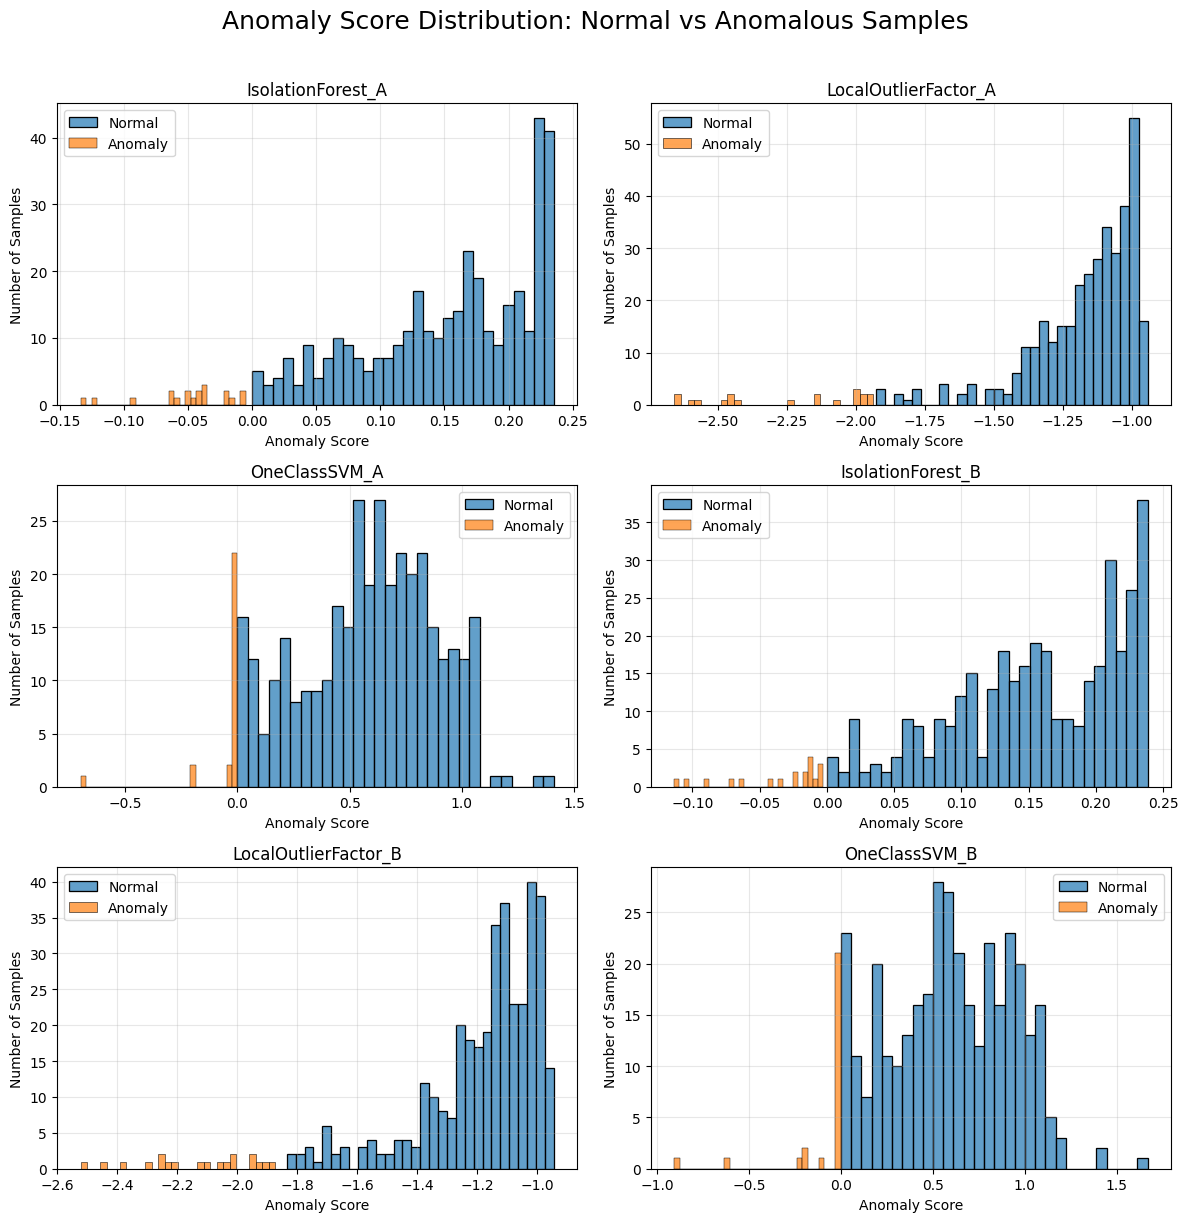

In [19]:
plot_anomaly_scores(scores, predictions)

### 4) Ranking the Most Anomalous Patients

In [24]:
# ----------------------------------------------------------
# Rank Most Anomalous Patients
# ----------------------------------------------------------

def rank_anomalies(
    X,
    labels,
    scores,
    top_n=10,
    ascending=True
):
    """
    Returns the most anomalous samples.

    Parameters
    ----------
    X : DataFrame
        Original feature set.

    labels : ndarray
        Prediction labels
        (-1 anomaly, 1 normal)

    scores : ndarray
        Decision scores.

    top_n : int
        Number of patients to display.

    ascending : bool
        True -> smaller score = more anomalous
        False -> larger score = more anomalous
    """

    results = X.copy()

    results.insert(
        0,
        "Patient",
        X.index
    )

    results["Anomaly"] = labels
    results["Score"] = scores

    anomalies = results[
        results["Anomaly"] == -1
    ].copy()

    anomalies = anomalies.sort_values(
        "Score",
        ascending=ascending
    )

    return anomalies.head(top_n)

In [25]:
# ----------------------------------------------------------
# Apply Ranking
# ----------------------------------------------------------

ranking_tables = {}

for name in predictions.keys():

    feature_set = name.split("_")[-1]

    X = X_A if feature_set == "A" else X_B

    ascending = True

    # Isolation Forest and OneClassSVM:
    # lower decision_function = more abnormal
    if "IsolationForest" in name:
        ascending = True

    elif "OneClassSVM" in name:
        ascending = True

    # LOF:
    # more negative = more abnormal
    elif "LocalOutlierFactor" in name:
        ascending = True

    ranking_tables[name] = rank_anomalies(
        X,
        predictions[name],
        scores[name],
        top_n=30,
        ascending=ascending
    )

#### - Inspect the anomalous patients detected by isolation forest for feature set A 

In [26]:
ranking_tables["IsolationForest_A"]

,Patient,con_num__Age,bin__Gender_F,bin__Gender_M,bin__Smoking_No,bin__Smoking_Yes,bin__Hx Smoking_No,bin__Hx Smoking_Yes,bin__Hx Radiothreapy_No,bin__Hx Radiothreapy_Yes,...,nom__Pathology_Hurthel cell,nom__Pathology_Micropapillary,nom__Pathology_Papillary,ord__Risk,ord__T,ord__N,ord__M,ord__Stage,Anomaly,Score
378,378,1.324077,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,...,1.0,0.0,0.0,0.0,6.0,2.0,0.0,3.0,-1,-0.133787
367,367,2.447768,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,...,0.0,0.0,0.0,0.0,5.0,0.0,1.0,4.0,-1,-0.123766
375,375,2.051171,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,...,0.0,0.0,1.0,0.0,6.0,2.0,1.0,4.0,-1,-0.093246
237,237,2.249470,0.0,1.0,0.0,1.0,1.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,2.0,0.0,1.0,4.0,-1,-0.062682
346,346,1.786773,0.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0,...,0.0,0.0,1.0,1.0,4.0,2.0,0.0,2.0,-1,-0.060870
376,376,2.646066,0.0,1.0,0.0,1.0,1.0,0.0,0.0,1.0,...,0.0,0.0,1.0,0.0,6.0,2.0,1.0,4.0,-1,-0.058091
374,374,0.332585,0.0,1.0,0.0,1.0,1.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,6.0,2.0,1.0,1.0,-1,-0.051025
363,363,1.522375,1.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,...,0.0,0.0,0.0,0.0,5.0,0.0,1.0,4.0,-1,-0.048927
348,348,1.191878,0.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0,...,1.0,0.0,0.0,1.0,4.0,0.0,0.0,0.0,-1,-0.046118
377,377,2.051171,0.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0,...,0.0,0.0,1.0,0.0,6.0,2.0,1.0,4.0,-1,-0.042357


In [27]:
ranking_tables["IsolationForest_A"].describe()

,Patient,con_num__Age,bin__Gender_F,bin__Gender_M,bin__Smoking_No,bin__Smoking_Yes,bin__Hx Smoking_No,bin__Hx Smoking_Yes,bin__Hx Radiothreapy_No,bin__Hx Radiothreapy_Yes,...,nom__Pathology_Hurthel cell,nom__Pathology_Micropapillary,nom__Pathology_Papillary,ord__Risk,ord__T,ord__N,ord__M,ord__Stage,Anomaly,Score
count,19.000000,19.000000,19.000000,19.000000,19.000000,19.000000,19.000000,19.000000,19.000000,19.000000,...,19.000000,19.000000,19.000000,19.000000,19.000000,19.000000,19.000000,19.000000,19.0,19.000000
mean,331.315789,1.327556,0.263158,0.736842,0.157895,0.842105,0.421053,0.578947,0.684211,0.315789,...,0.105263,0.052632,0.526316,0.368421,4.473684,1.157895,0.578947,2.368421,-1.0,-0.049579
std,84.188316,1.115338,0.452414,0.452414,0.374634,0.374634,0.507257,0.507257,0.477567,0.477567,...,0.315302,0.229416,0.512989,0.683986,1.576509,1.014515,0.507257,1.605910,0.0,0.034946
min,29.000000,-0.725007,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-1.0,-0.133787
25%,347.000000,0.762231,0.000000,0.500000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,4.000000,0.000000,0.000000,1.000000,-1.0,-0.059480
50%,363.000000,1.720674,0.000000,1.000000,0.000000,1.000000,0.000000,1.000000,1.000000,0.000000,...,0.000000,0.000000,1.000000,0.000000,5.000000,2.000000,1.000000,2.000000,-1.0,-0.042357
75%,372.500000,2.051171,0.500000,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,0.000000,0.000000,1.000000,0.500000,5.500000,2.000000,1.000000,4.000000,-1.0,-0.028646
max,378.000000,2.646066,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,2.000000,6.000000,2.000000,1.000000,4.000000,-1.0,-0.005077


#### - Get A few anomalous patients from the original dataset with unscaled features

In [59]:
# Isolation forest for feature set A
patients_indices = ranking_tables["IsolationForest_A"].Patient
org_dataset.iloc[patients_indices]

,Age,Gender,Smoking,Hx Smoking,Hx Radiothreapy,Thyroid Function,Physical Examination,Adenopathy,Pathology,Focality,Risk,T,N,M,Stage,Response,Recurred
378,72,M,Yes,Yes,Yes,Euthyroid,Single nodular goiter-right,Right,Papillary,Uni-Focal,High,T4b,N1b,M1,IVB,Biochemical Incomplete,Yes
367,80,M,Yes,No,No,Euthyroid,Single nodular goiter-left,No,Hurthel cell,Multi-Focal,Intermediate,T4a,N0,M0,II,Structural Incomplete,Yes
375,59,F,No,No,No,Euthyroid,Multinodular goiter,Bilateral,Papillary,Multi-Focal,High,T4b,N1b,M0,IVB,Structural Incomplete,Yes
237,36,M,No,No,No,Clinical Hyperthyroidism,Multinodular goiter,No,Papillary,Uni-Focal,Intermediate,T2,N1a,M0,I,Indeterminate,Yes
346,32,M,No,Yes,No,Euthyroid,Multinodular goiter,Bilateral,Papillary,Multi-Focal,Intermediate,T3b,N1b,M0,I,Structural Incomplete,Yes
376,40,M,Yes,No,No,Euthyroid,Multinodular goiter,Bilateral,Papillary,Multi-Focal,High,T4b,N1b,M0,I,Structural Incomplete,Yes
374,62,M,Yes,No,No,Euthyroid,Single nodular goiter-left,Left,Papillary,Multi-Focal,High,T4a,N1b,M1,IVB,Structural Incomplete,Yes
363,67,F,No,No,No,Euthyroid,Single nodular goiter-right,Right,Papillary,Multi-Focal,High,T4a,N1b,M0,III,Structural Incomplete,Yes
348,58,F,No,No,No,Subclinical Hypothyroidism,Multinodular goiter,Extensive,Papillary,Multi-Focal,Intermediate,T3b,N1b,M0,II,Structural Incomplete,Yes
377,46,M,Yes,No,No,Euthyroid,Single nodular goiter-left,Bilateral,Follicular,Uni-Focal,High,T4b,N1b,M1,II,Structural Incomplete,Yes


### 5) Visualize a complete anomaly detection result

In [57]:
# ==========================================================
# Visualize Anomaly Detection Results
# ==========================================================

def plot_anomaly_dashboard(
    X_A,
    X_B,
    y,
    predictions
):

    datasets = {
        "A": X_A,
        "B": X_B
    }

    algorithms = [
        "IsolationForest",
        "LocalOutlierFactor",
        "OneClassSVM"
    ]

    fig, axes = plt.subplots(
        len(algorithms),
        2,
        figsize=(14, 15)
    )

    # Make axes always 2D
    if len(algorithms) == 1:
        axes = np.array([axes])

    y_true = y.values.ravel()

    for row, algorithm in enumerate(algorithms):

        for col, (feature_set, X) in enumerate(datasets.items()):

            ax = axes[row, col]

            # ----------------------------------------
            # PCA Projection
            # ----------------------------------------

            pca = PCA(
                n_components=2,
                random_state=42
            )

            X_pca = pca.fit_transform(X)

            # ----------------------------------------
            # Predicted anomaly labels
            # ----------------------------------------

            labels = predictions[f"{algorithm}_{feature_set}"]

            # ----------------------------------------
            # Masks
            # ----------------------------------------

            class0 = (y_true == 0)
            class1 = (y_true == 1)

            normal = (labels == 1)
            anomaly = (labels == -1)

            # ========================================
            # Normal Patients
            # ========================================

            ax.scatter(
                X_pca[class0 & normal, 0],
                X_pca[class0 & normal, 1],
                color="royalblue",
                s=35,
                alpha=0.75,
                label="Class 0",
                zorder=1
            )

            ax.scatter(
                X_pca[class1 & normal, 0],
                X_pca[class1 & normal, 1],
                color="crimson",
                s=35,
                alpha=0.75,
                label="Class 1",
                zorder=1
            )

            # ========================================
            # Anomalies
            # ========================================

            ax.scatter(
                X_pca[class0 & anomaly, 0],
                X_pca[class0 & anomaly, 1],
                marker="*",
                color="royalblue",
                edgecolor="black",
                linewidth=1,
                s=160,
                label="Class 0 Anomaly",
                zorder=5
            )

            ax.scatter(
                X_pca[class1 & anomaly, 0],
                X_pca[class1 & anomaly, 1],
                marker="*",
                color="crimson",
                edgecolor="black",
                linewidth=1,
                s=160,
                label="Class 1 Anomaly",
                zorder=5
            )

            # ----------------------------------------
            # Formatting
            # ----------------------------------------

            ax.set_title(
                f"{algorithm} - Feature Set {feature_set}",
                fontsize=12,
                weight="bold"
            )

            ax.set_xlabel("Principal Component 1")
            ax.set_ylabel("Principal Component 2")

            ax.grid(alpha=0.30)

            ax.legend(
                fontsize=8,
                framealpha=0.95
            )

    plt.suptitle(
        "Anomaly Detection Visualization",
        fontsize=18,
        weight="bold",
        y=1.01
    )

    plt.tight_layout()
    plt.show()

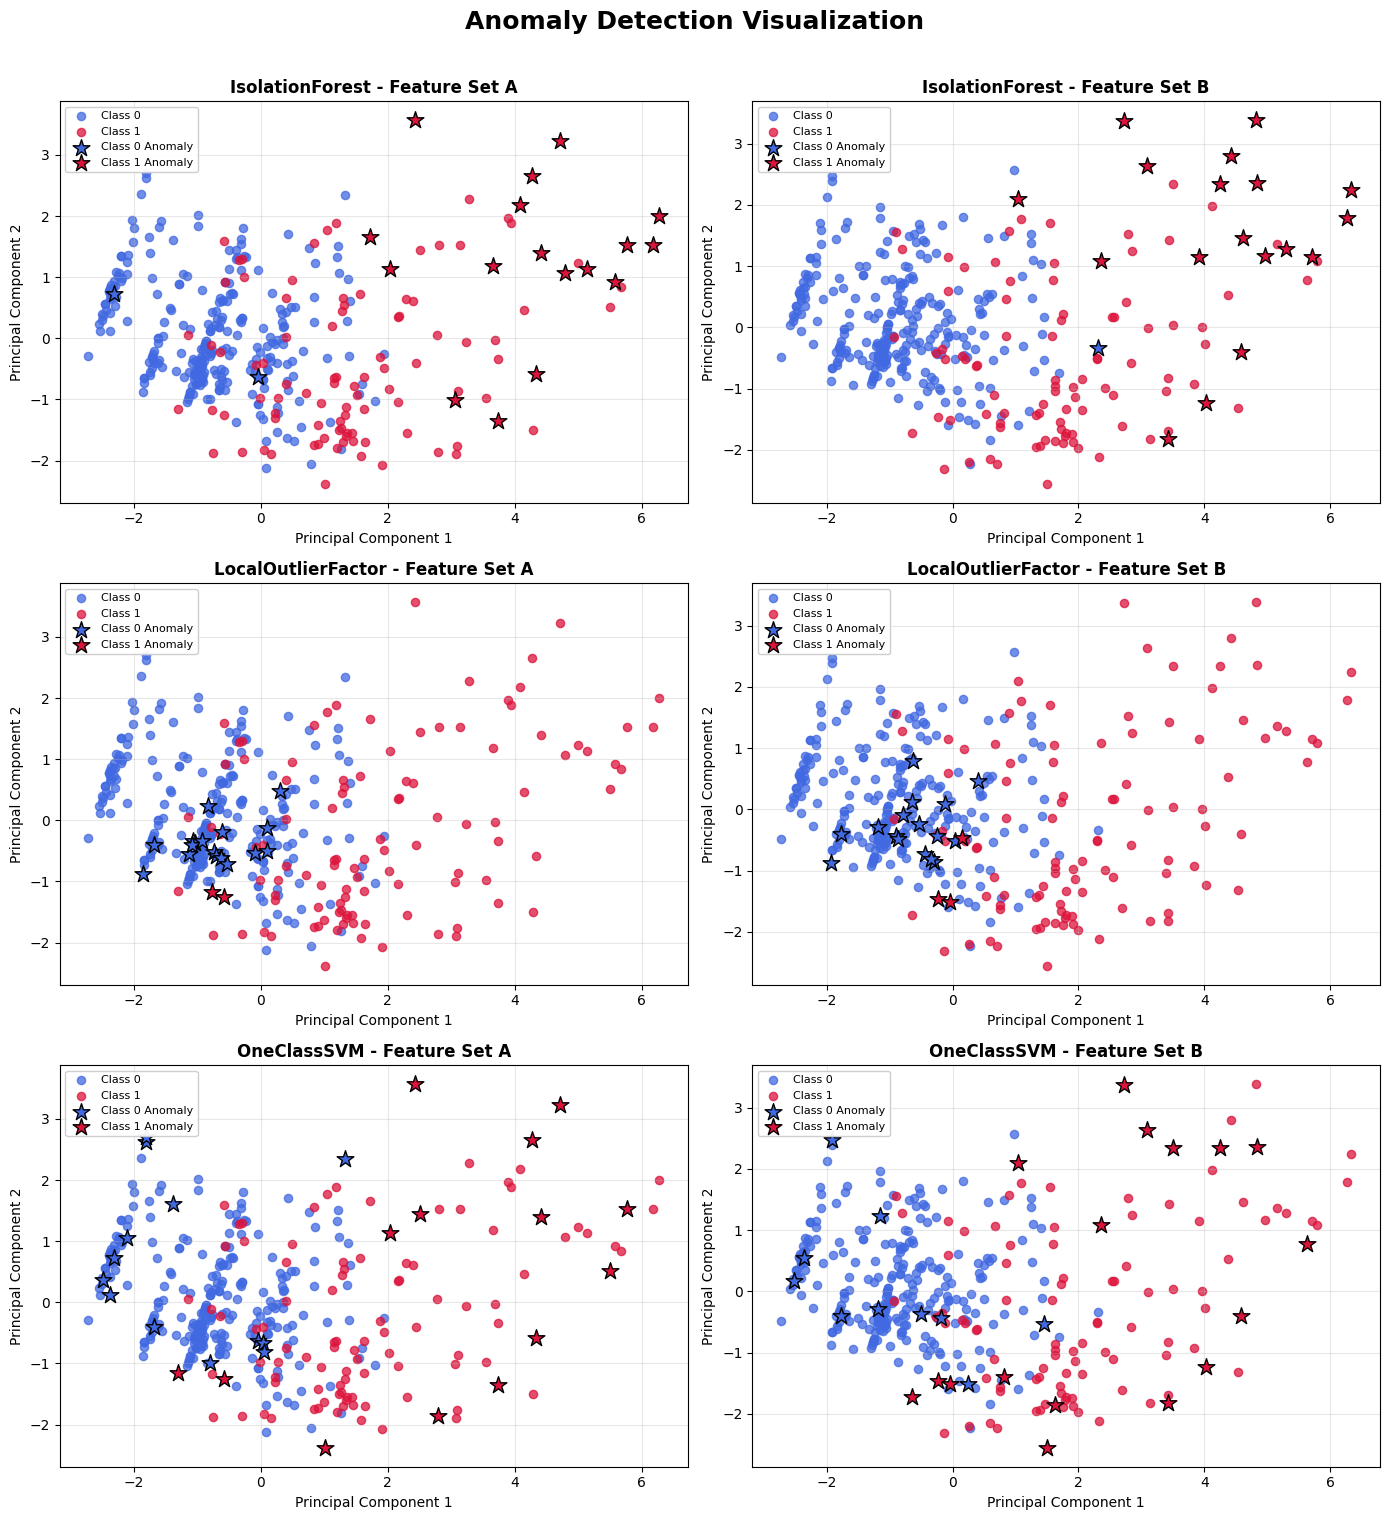

In [58]:
plot_anomaly_dashboard(
    X_A,
    X_B,
    y,
    predictions
)

### 6) Evaluation of algorithms

In [95]:
def evaluate_anomaly_detection(
    predictions,
    y_true
):

    results = []
    c_matrices = []

    y_true = y_true.values.ravel()

    for name, labels in predictions.items():

        # Convert:
        # normal = 0
        # anomaly = 1
        y_pred = np.where(labels == -1, 1, 0)

        precision = precision_score(
            y_true,
            y_pred,
            zero_division=0
        )

        recall = recall_score(
            y_true,
            y_pred,
            zero_division=0
        )

        f1 = f1_score(
            y_true,
            y_pred,
            zero_division=0
        )

        cm = confusion_matrix(
            y_true,
            y_pred
        )

        tn, fp, fn, tp = cm.ravel()

        results.append({
            "Algorithm": name.split("_")[0],
            "Feature Set": name.split("_")[1],
            "Precision": precision,
            "Recall": recall,
            "F1-score": f1,
            "True Positives": tp,
            "False Positives": fp,
            "False Negatives": fn,
            "True Negatives": tn
        })

        c_matrices.append({
            "Confusion Matrix": cm
        })

    return pd.DataFrame(results), c_matrices

In [96]:
anomaly_results, cms = evaluate_anomaly_detection(
    predictions,
    y
)

anomaly_results

,Algorithm,Feature Set,Precision,Recall,F1-score,True Positives,False Positives,False Negatives,True Negatives
0,IsolationForest,A,0.894737,0.157407,0.267717,17,2,91,270
1,LocalOutlierFactor,A,0.105263,0.018519,0.031496,2,17,106,255
2,OneClassSVM,A,0.518519,0.129630,0.207407,14,13,94,259
3,IsolationForest,B,0.947368,0.166667,0.283465,18,1,90,271
4,LocalOutlierFactor,B,0.157895,0.027778,0.047244,3,16,105,256
5,OneClassSVM,B,0.629630,0.157407,0.251852,17,10,91,262


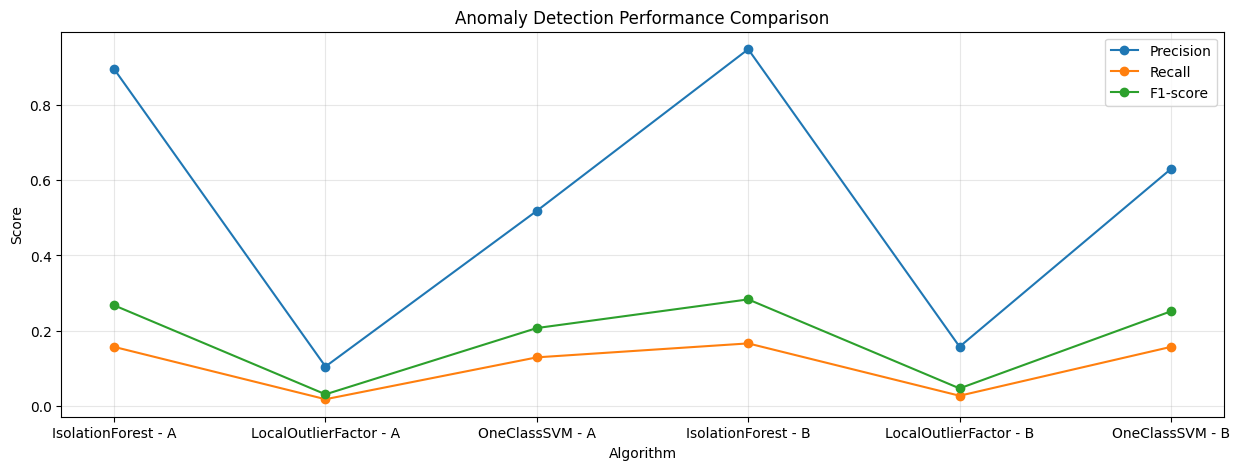

In [110]:
def plot_eval_metrics(anomaly_results):

    anomaly_results[["Precision", "Recall", "F1-score"]].plot(
        figsize=(15, 5),
        title= "Anomaly Detection Performance Comparison",
        xlabel="Algorithm",
        ylabel="Score",
        grid=True,
        marker='o'
    )

    xlabels = []

    for name, set in zip(anomaly_results["Algorithm"], anomaly_results["Feature Set"]):
        xlabels.append(f"{name} - {set}")

    plt.xticks(anomaly_results.index, xlabels)
    plt.grid(alpha=0.3)
    plt.show()

plot_eval_metrics(anomaly_results)

In [107]:
# ----------------------------------------------------------
# Confusion Matrix Visualization
# ----------------------------------------------------------
def plot_confusion_matrix(cms):

    algorithms = [
        "IsolationForest",
        "LocalOutlierFactor",
        "OneClassSVM"
    ]

    datasets = [
        "A",
        "B"
    ]

    fig, axes = plt.subplots(
        3,
        2,
        figsize=(13, 15)
    )


    index = 0

    for row, algorithm in enumerate(algorithms):

        for col, feature_set in enumerate(datasets):

            ax = axes[row, col]
            cm = cms[index]["Confusion Matrix"]

            sns.heatmap(
                cm,
                annot=True,
                fmt="d",
                cmap="RdGy",
                cbar=False,
                ax=ax
            )

            ax.set_title(f"{algorithm} - Feature Set {feature_set}", fontsize=12)
            ax.set_xlabel("Predicted")
            ax.set_ylabel("Actual")
            ax.set_xticklabels(["Normal", "Anomaly"])
            ax.set_yticklabels(["Normal", "Anomaly"], rotation=0)

            index += 1

    plt.suptitle(
        "Confusion Matrices - Anomaly Detection",
        fontsize=18,
        weight="bold", y=1.01
    )

    plt.tight_layout()
    plt.show()

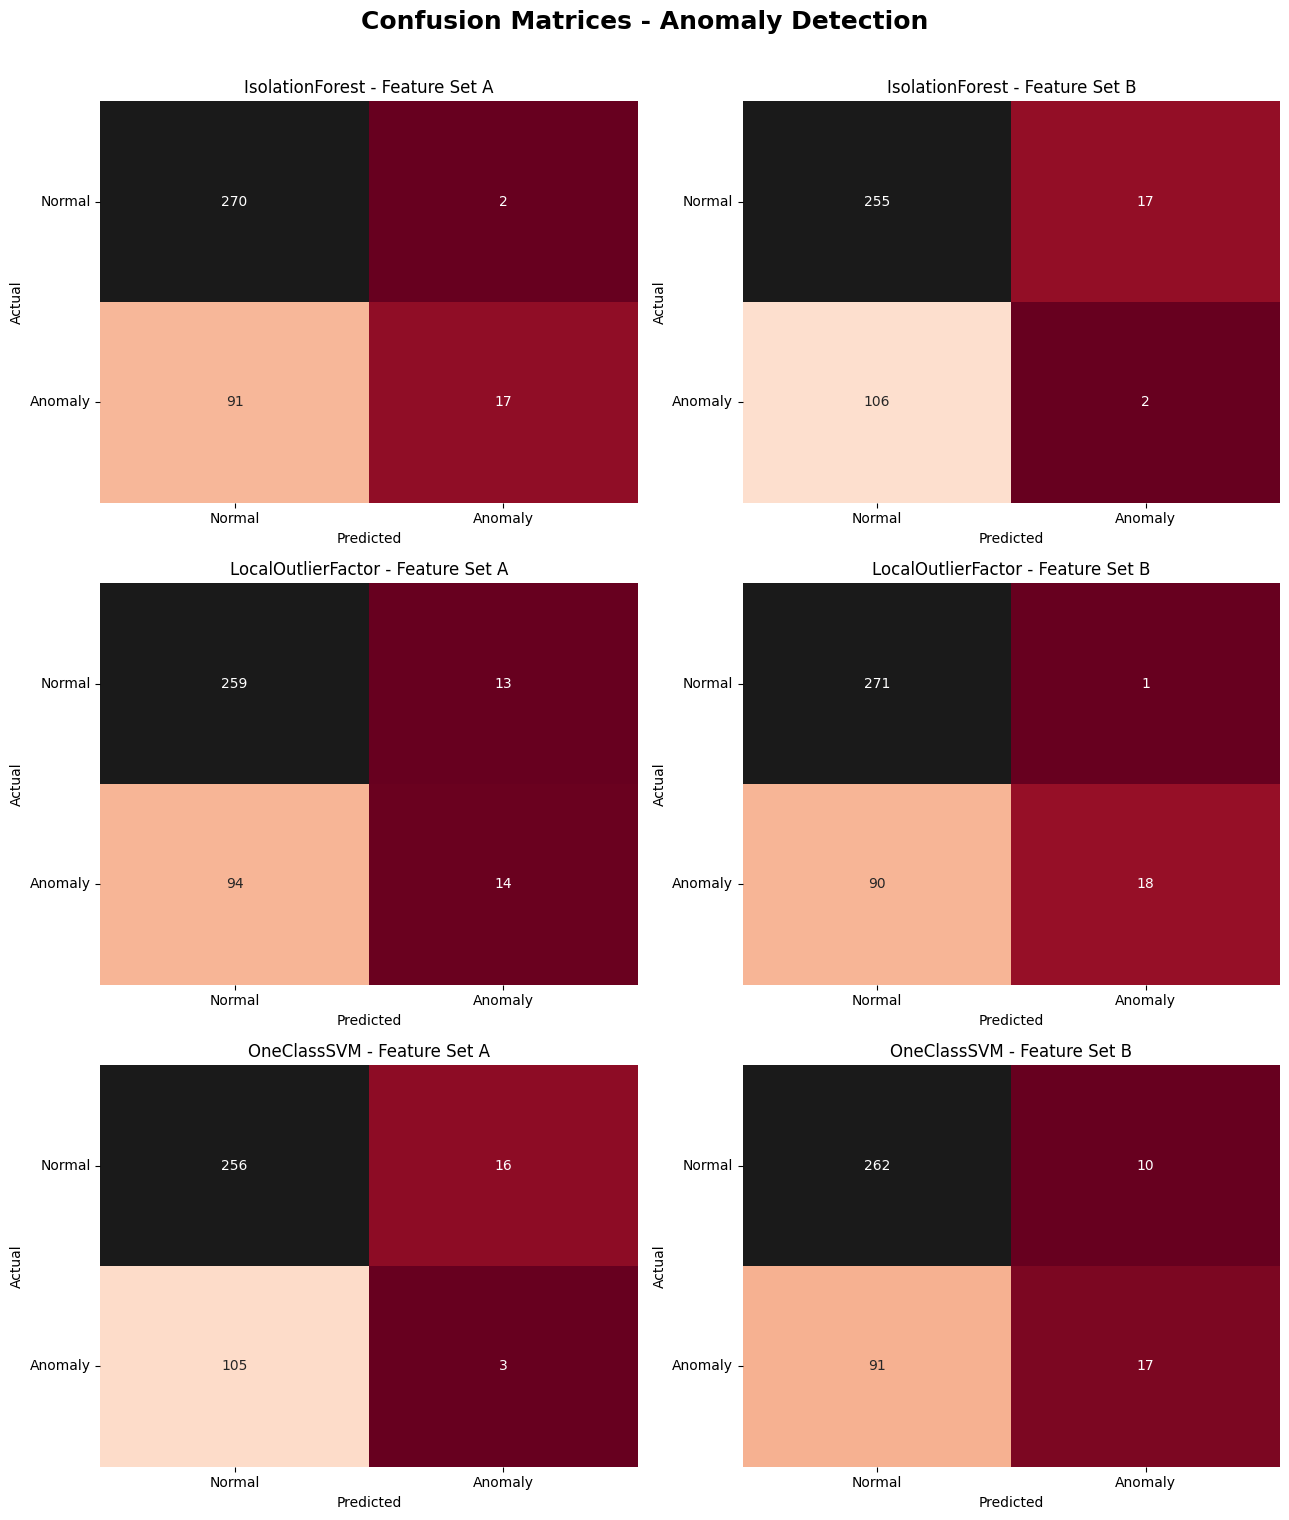

In [108]:
plot_confusion_matrix(cms)

> The anomaly detection algorithms successfully identified a small subset of unusual patients, but many recurrent patients were not detected because recurrence does not necessarily imply statistical abnormality.

### - Final Ranking
| Rank | Algorithm        | Feature       |
| ---- | ---------------- | ------------- |
| 🥇 1 | Isolation Forest | Feature Set B |
| 🥈 2 | One-Class SVM    | Feature Set B |
| 🥉 3 | Isolation Forest | Feature Set A |
| 4    | One-Class SVM    | Feature Set A |
| 5    | LOF              | Feature Set B |
| 6    | LOF              | Feature Set A |


### 7) Save the best algorithm

In [114]:
# ----------------------------------------------------------
# Train & Save Best Anomaly Detection Model
# ----------------------------------------------------------

best_model = IsolationForest(
    contamination=0.05,
    random_state=42
)

# Train on the best feature set (B)
best_model.fit(X_B)

best_anomaly_model = {

    "algorithm": "IsolationForest",

    "feature_set": "B",

    "model": best_model,

    "metrics": {
        "Precision": 0.947368,
        "Recall": 0.166667,
        "F1-score": 0.283465
    }
}


joblib.dump(best_anomaly_model, PROJECT_ROOT / "Models" / "best_anomaly_detector_thyroid.pkl")


['F:\\Desktop\\Projects\\AI-ML-DL\\BioDiscovery-Exploring-Hidden-Patterns-in-Biomedical-Data\\Models\\best_anomaly_detector_thyroid.pkl']

# Conclusion

In this notebook, unsupervised anomaly detection techniques were applied
to identify unusual patient profiles within thyroid cancer clinical data.

Three algorithms were benchmarked:

- Isolation Forest
- Local Outlier Factor
- One-Class SVM


The experiments were performed using two different feature representations
(Feature Set A and Feature Set B).


Among all approaches, Isolation Forest trained on Feature Set B achieved
the best overall performance, obtaining the highest precision and F1-score.

This indicates that Feature Set B provides a more meaningful representation
for identifying rare patient patterns.

The results also highlight an important characteristic of anomaly detection:
while detected anomalies can provide valuable insights into unusual cases,
unsupervised methods cannot guarantee that every clinically abnormal patient
will be detected.

Therefore, anomaly detection should be considered as an exploratory tool
for discovering rare patterns and supporting further clinical investigation,
rather than a replacement for supervised diagnostic models.